# 4.1 — Monte Carlo: fundamentos, barras de error y sesgo de discretización

Los tres módulos anteriores construyeron precios *exactos*: fórmulas cerradas, árboles que convergen, esperanzas que se resuelven completando el cuadrado. Ese lujo se acaba aquí. En cuanto el modelo tiene más de un factor, el payoff mira la trayectoria completa o la volatilidad es estocástica, la integral que define el precio deja de tener primitiva y hay que estimarla. Monte Carlo es la herramienta que escala a esos casos, y su propiedad estructural es que **su tasa de convergencia $O(n^{-1/2})$ no depende de la dimensión**: valuar una canasta de 50 subyacentes cuesta lo mismo por trayectoria que valuar uno solo. Ninguna cuadratura determinista puede decir eso.

El precio de esa generalidad es que un resultado de Monte Carlo **no es un número, es un intervalo**, y que ese intervalo puede estar centrado en el lugar equivocado. El error total de un estimador MC se parte en dos piezas de naturaleza distinta:
$$
\underbrace{\hat V_{n,m} - V}_{\text{error total}} \;=\; \underbrace{\big(\mathbb{E}[\hat V_{n,m}] - V\big)}_{\text{sesgo de discretización } b(m)} \;+\; \underbrace{\big(\hat V_{n,m} - \mathbb{E}[\hat V_{n,m}]\big)}_{\text{error estadístico } O_p(n^{-1/2})}
$$
y sólo el segundo aparece en las barras de error. El primero es **invisible** para el Monte Carlo: se puede correr con mil millones de trayectorias, obtener un intervalo de confianza estrechísimo, y que el precio verdadero esté fuera. Es exactamente el error que hizo fallar la validación del lookback en 3.3 y el que hacía pasar de milagro la asiática geométrica. Este notebook lo mide, lo separa del error estadístico y establece el vocabulario — convergencia débil y fuerte, Euler y Milstein — con el que M4 entero va a razonar.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from qflib.black import bs_price
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

# Canonical parameters
S0, K, r, q, sigma, T = 100.0, 100.0, 0.05, 0.0, 0.20, 1.0
bs_call = bs_price(S0, K, r, q, sigma, T, "call")

print(f"S0={S0}, K={K}, r={r}, q={q}, sigma={sigma}, T={T}")
print(f"Referencia exacta: call europeo (Black-Scholes) = {bs_call:.10f}")

S0=100.0, K=100.0, r=0.05, q=0.0, sigma=0.2, T=1.0
Referencia exacta: call europeo (Black-Scholes) = 10.4505835722


## 1. El estimador y su barra de error

Queremos $V=\mathbb{E}^{\mathbb{Q}}[Y]$ con $Y=e^{-rT}g(S_T)$. El estimador es el promedio muestral sobre $n$ trayectorias independientes,
$$
\hat V_n = \frac1n\sum_{i=1}^n Y_i, \qquad \mathbb{E}[\hat V_n]=V \ \ \text{(insesgado)}, \qquad \text{Var}(\hat V_n)=\frac{\sigma_Y^2}{n}.
$$
La ley de los grandes números da consistencia, pero la que sirve para trabajar es el **teorema central del límite**, porque cuantifica el error:
$$
\sqrt{n}\,\big(\hat V_n - V\big) \ \xrightarrow{\ d\ }\ \mathcal{N}(0,\sigma_Y^2)
\qquad\Longrightarrow\qquad
\hat V_n \approx V + \frac{\sigma_Y}{\sqrt n}\,\mathcal{N}(0,1).
$$
Como $\sigma_Y$ no se conoce, se estima con la desviación muestral $s_n$ y se reporta el **error estándar** $\text{SE}=s_n/\sqrt n$ y el intervalo de confianza asintótico al $95\%$:
$$
\Big[\hat V_n - 1.96\,\frac{s_n}{\sqrt n},\ \ \hat V_n + 1.96\,\frac{s_n}{\sqrt n}\Big].
$$
Tres advertencias que conviene tener presentes desde el principio, porque explican casi todos los malentendidos con Monte Carlo:

1. **El IC es asintótico.** El $95\%$ vale en el límite; con $n$ chico, o con payoffs de cola muy pesada (una digital deep OTM, un payoff con $\sigma_Y$ enorme), la cobertura real puede ser bastante menor. En la §2 lo medimos en vez de creerlo.
2. **$s_n$ es aleatorio.** El intervalo tiene ancho aleatorio, no sólo centro aleatorio. Estrictamente, el IC exacto usaría la $t$ de Student, pero con $n\geq10^3$ la diferencia es irrelevante.
3. **El IC no dice nada sobre el sesgo.** Es un intervalo alrededor de $\mathbb{E}[\hat V_n]$, no alrededor de $V$. Si el estimador es sesgado, el IC se encoge con $n$ alrededor del número equivocado — la §3 completa.

**El costo.** De $\text{SE}\propto n^{-1/2}$ sale la aritmética incómoda del método: **para ganar un dígito decimal hay que multiplicar el trabajo por 100**, y para partir el error a la mitad, por 4. A cambio, esa tasa es la misma en dimensión $1$ que en dimensión $50$ — mientras que una cuadratura con $N$ nodos por eje necesita $N^d$ evaluaciones y muere alrededor de $d\approx5$. Todo M4 es, en el fondo, la lucha por mejorar la constante $\sigma_Y$ (reducción de varianza, §4.2-4.3) o por cambiar la tasa misma (QMC, §4.3), dado que el exponente $-1/2$ no se puede tocar por otros medios.

        n |         MC |        SE |                 IC 95% | |MC-BS|/SE | cubre BS?
----------------------------------------------------------------------------------
     1000 |   9.911980 |  0.448345 | [ 9.033223, 10.790736] |      1.201 |      True
    10000 |  10.388669 |  0.148139 | [10.098317, 10.679021] |      0.418 |      True
   100000 |  10.426005 |  0.046843 | [10.334193, 10.517817] |      0.525 |      True
  1000000 |  10.457763 |  0.014724 | [10.428903, 10.486623] |      0.488 |      True

pendiente log-log de SE vs n = -0.4951   (teoria: -1/2)


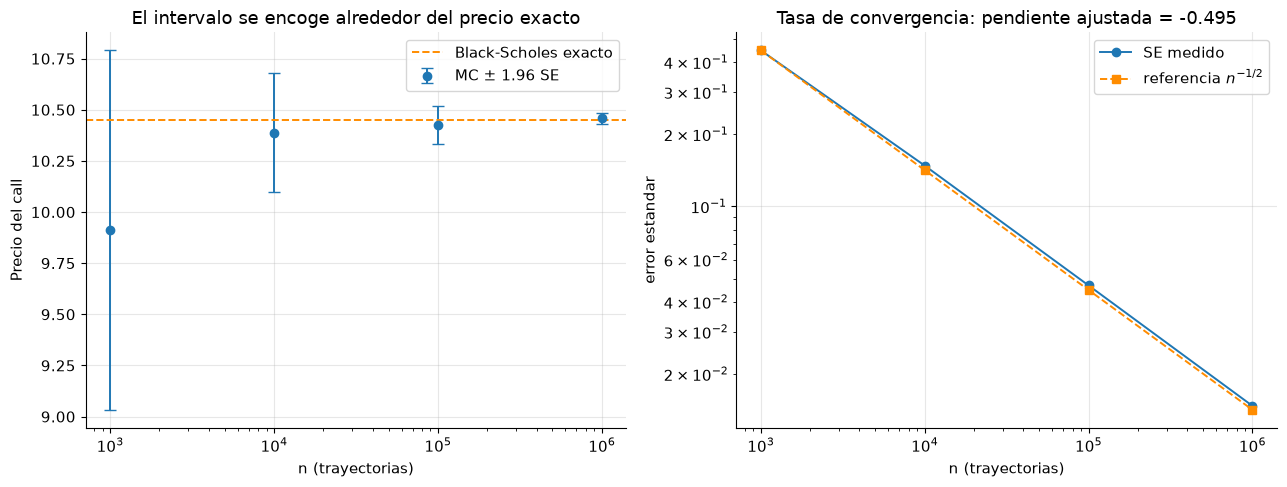

In [2]:
def mc_call_terminal(n_paths, rng, S0=S0, K=K, r=r, q=q, sigma=sigma, T=T):
    '''Plain MC price of a European call, sampling S_T exactly (no time discretization).'''
    Z = rng.standard_normal(n_paths)
    S_T = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    disc_payoff = np.exp(-r * T) * np.maximum(S_T - K, 0.0)
    mean = disc_payoff.mean()
    se = disc_payoff.std(ddof=1) / np.sqrt(n_paths)
    return mean, se


n_grid = np.array([10**3, 10**4, 10**5, 10**6])
means, ses = [], []
for n in n_grid:
    m, s = mc_call_terminal(int(n), rng)
    means.append(m); ses.append(s)
means, ses = np.array(means), np.array(ses)

print(f"{'n':>9} | {'MC':>10} | {'SE':>9} | {'IC 95%':>22} | {'|MC-BS|/SE':>10} | {'cubre BS?':>9}")
print("-" * 82)
for n, m, s in zip(n_grid, means, ses):
    lo, hi = m - 1.96 * s, m + 1.96 * s
    print(f"{n:>9} | {m:>10.6f} | {s:>9.6f} | [{lo:>9.6f}, {hi:>9.6f}] | {abs(m-bs_call)/s:>10.3f} | "
          f"{str(lo <= bs_call <= hi):>9}")

slope_se = np.polyfit(np.log(n_grid), np.log(ses), 1)[0]
print(f"\npendiente log-log de SE vs n = {slope_se:.4f}   (teoria: -1/2)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(n_grid, means, yerr=1.96 * ses, fmt="o", capsize=4, label="MC $\\pm$ 1.96 SE")
ax.axhline(bs_call, color="darkorange", ls="--", label="Black-Scholes exacto")
ax.set_xscale("log")
ax.set_xlabel("n (trayectorias)"); ax.set_ylabel("Precio del call")
ax.set_title("El intervalo se encoge alrededor del precio exacto")
ax.legend()

ax = axes[1]
ax.plot(n_grid, ses, "o-", label="SE medido")
ax.plot(n_grid, ses[0] * (n_grid / n_grid[0]) ** -0.5, "s--", color="darkorange",
        label="referencia $n^{-1/2}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("n (trayectorias)"); ax.set_ylabel("error estandar")
ax.set_title(f"Tasa de convergencia: pendiente ajustada = {slope_se:.3f}")
ax.legend()

plt.tight_layout()
plt.show()

## 2. Demo 2 — ¿el intervalo del 95% cubre el 95% de las veces?

El IC es una afirmación falsable y conviene tratarla como tal. El experimento: repetir $R=2000$ veces la valuación completa con $n=10^4$ trayectorias independientes, construir cada intervalo, y contar en qué fracción de ellos cae el precio de Black-Scholes — que aquí conocemos exactamente. La respuesta debe ser $\approx0.95$; el error de esa estimación es $\sqrt{0.95\cdot0.05/R}\approx0.005$, así que cualquier valor entre $0.94$ y $0.96$ es consistente.

Vale la pena notar por qué este experimento es honesto: aquí **no hay sesgo** — se muestrea $S_T$ con la solución exacta de la SDE, no con una discretización — así que el único error presente es el estadístico y el TCL puede lucirse. En la §3 rompemos justamente ese supuesto y el mismo diagnóstico da otra cosa.

Replicas: R=2000, cada una con n=10000
Cobertura empirica del IC 95% = 0.9550  (nominal 0.95 +- 0.0096)
z-scores: media = -0.0427 (teoria 0), desv. est. = 0.9710 (teoria 1)


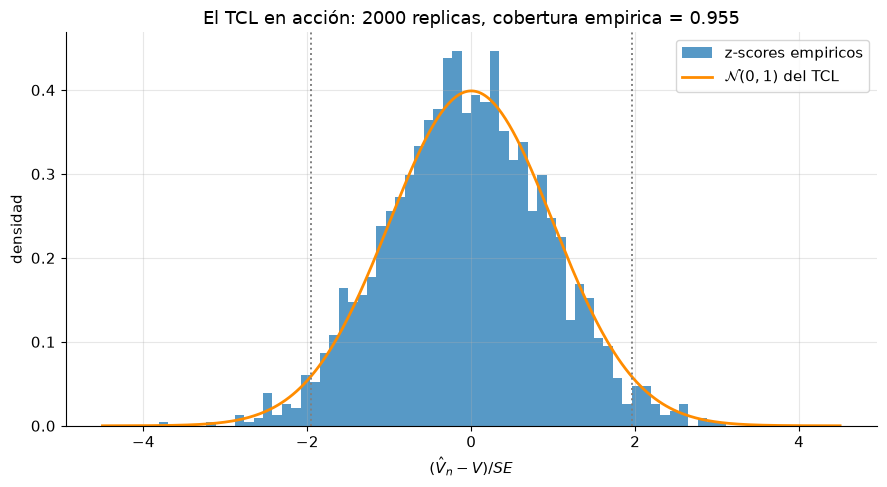

In [3]:
R_reps, n_rep = 2000, 10_000
rng_cov = np.random.default_rng(7)

hits = 0
z_scores = []
batch = 250  # se procesa por lotes para no alojar R x n normales de una vez
for start in range(0, R_reps, batch):
    b = min(batch, R_reps - start)
    Z = rng_cov.standard_normal((b, n_rep))
    S_T = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    disc_payoff = np.exp(-r * T) * np.maximum(S_T - K, 0.0)
    m = disc_payoff.mean(axis=1)
    s = disc_payoff.std(axis=1, ddof=1) / np.sqrt(n_rep)
    hits += int(((m - 1.96 * s <= bs_call) & (bs_call <= m + 1.96 * s)).sum())
    z_scores.append((m - bs_call) / s)

z_scores = np.concatenate(z_scores)
coverage = hits / R_reps
mc_se_cov = np.sqrt(0.95 * 0.05 / R_reps)
print(f"Replicas: R={R_reps}, cada una con n={n_rep}")
print(f"Cobertura empirica del IC 95% = {coverage:.4f}  (nominal 0.95 +- {1.96*mc_se_cov:.4f})")
print(f"z-scores: media = {z_scores.mean():+.4f} (teoria 0), desv. est. = {z_scores.std(ddof=1):.4f} (teoria 1)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(z_scores, bins=60, density=True, alpha=0.75, label="z-scores empiricos")
grid = np.linspace(-4.5, 4.5, 400)
ax.plot(grid, norm.pdf(grid), color="darkorange", lw=2, label="$\\mathcal{N}(0,1)$ del TCL")
for lim in (-1.96, 1.96):
    ax.axvline(lim, color="gray", ls=":")
ax.set_xlabel("$(\\hat V_n - V)/SE$"); ax.set_ylabel("densidad")
ax.set_title(f"El TCL en acción: {R_reps} replicas, cobertura empirica = {coverage:.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Sesgo de discretización: el error que las barras de error no ven

Hasta aquí simulamos $S_T$ con la **solución exacta** de la SDE, que para el GBM existe. En cuanto el modelo no tiene solución cerrada (Heston, SABR, un LMM) hay que discretizar la SDE, y ahí entra un error de naturaleza distinta. El esquema de **Euler-Maruyama** para $dS_t=\mu S_tdt+\sigma S_tdW_t$ es
$$
\hat S_{k+1} = \hat S_k\big(1+\mu\Delta t+\sigma\Delta W_k\big), \qquad \Delta W_k\sim\mathcal{N}(0,\Delta t),
$$
y no reproduce la ley de $S_T$: la aproximación produce un proceso *distinto*, cuyo error se mide de dos maneras que no hay que confundir.

**Convergencia débil** — el error en esperanzas, que es lo que le importa a un pricer:
$$
\big|\mathbb{E}[f(\hat S_T)] - \mathbb{E}[f(S_T)]\big| = O(\Delta t) \qquad \text{(orden 1 para Euler)}.
$$
**Convergencia fuerte** — el error trayectoria a trayectoria, con el *mismo* browniano:
$$
\mathbb{E}\big|\hat S_T - S_T\big| = O(\sqrt{\Delta t}) \qquad \text{(orden } \tfrac12 \text{ para Euler)}.
$$
El orden fuerte es peor porque exige seguir la trayectoria, no sólo acertarle a la distribución. Para un payoff europeo sólo importa el débil; el fuerte manda cuando el payoff mira la trayectoria (barreras, lookbacks) y es lo que gobierna la eficiencia de multilevel Monte Carlo (Giles 2008, fuera de alcance aquí).

**Milstein** añade el término de orden siguiente en la expansión de Itô-Taylor, $\tfrac12\sigma\sigma'(S)\big((\Delta W)^2-\Delta t\big)$, que para el GBM ($\sigma(S)=\sigma S$, $\sigma'=\sigma$) es $\tfrac12\sigma^2S_k\big((\Delta W_k)^2-\Delta t\big)$:
$$
\hat S_{k+1} = \hat S_k\Big(1+\mu\Delta t+\sigma\Delta W_k+\tfrac12\sigma^2\big((\Delta W_k)^2-\Delta t\big)\Big).
$$
Eso sube el orden **fuerte** a $1$ dejando el débil igual en $1$ — mejora la trayectoria, no la esperanza.

**Cómo medir el sesgo sin que el ruido lo tape.** Aquí está el truco metodológico del notebook: si comparamos el Euler contra Black-Scholes, el error que veremos es sesgo *más* ruido MC, y con $n=10^6$ el ruido ($\text{SE}\approx0.015$) es del mismo orden que el sesgo a $m$ grande. La solución son **números aleatorios comunes**: simulamos una malla fina de incrementos brownianos una sola vez, construimos las mallas gruesas **sumando** incrementos adyacentes (así todas comparten el mismo $W_T$), y comparamos cada Euler contra el simulador exacto evaluado sobre *ese mismo* browniano. El ruido se cancela casi por completo en la diferencia y queda el sesgo limpio — la misma idea que la malla anidada del lookback en 3.3. Como bono, el estimador de la diferencia trae su propio error estándar, así que podemos decir cuánto sesgo somos capaces de *resolver*.

Una advertencia sobre cómo se verifica el orden, porque es fácil engañarse: la teoría dice
$$
\text{sesgo}(m) = \frac{c_1}{m} + \frac{c_2}{m^2} + O(m^{-3}),
$$
y ajustar una recta al log-log de $|\text{sesgo}|$ estima el orden **sólo si el primer término ya domina**. En el rango de $m$ que cabe en un notebook eso no pasa: veremos una pendiente cercana a $-1.2$, no a $-1$, y no porque Euler sea de orden $1.2$ sino porque $c_2$ todavía pesa. Por eso abajo hacemos las dos cosas: reportamos la pendiente (como diagnóstico grueso) y **ajustamos los dos términos por mínimos cuadrados**, que es la afirmación que de verdad se puede verificar — si la estructura teórica es correcta, ese ajuste de dos parámetros debe reproducir ocho mediciones casi exactamente.

Simulador exacto (n=1,000,000, brownianos comunes) = 10.449556   [BS = 10.450584]
    m |      Euler |      sesgo | SE del sesgo | |sesgo|/SE |   sesgo*m
------------------------------------------------------------------------
    1 |  10.202977 |  -0.246579 |     0.002647 |       93.2 |  -0.24658
    2 |  10.358630 |  -0.090926 |     0.001754 |       51.8 |  -0.18185
    4 |  10.413009 |  -0.036547 |     0.001218 |       30.0 |  -0.14619
    8 |  10.433487 |  -0.016069 |     0.000859 |       18.7 |  -0.12856
   16 |  10.441739 |  -0.007817 |     0.000606 |       12.9 |  -0.12508
   32 |  10.446294 |  -0.003262 |     0.000429 |        7.6 |  -0.10437
   64 |  10.447886 |  -0.001670 |     0.000304 |        5.5 |  -0.10685
  128 |  10.448855 |  -0.000701 |     0.000215 |        3.3 |  -0.08979

pendiente log-log (m=1..16) = -1.2459  <- mas empinada que -1: el termino c2/m^2 aun pesa
ajuste de dos terminos: c1 = -0.114953, c2 = -0.131723   (c2/c1 = 1.15)
  R^2 con c1/m + c2/m^2 = 0.999983

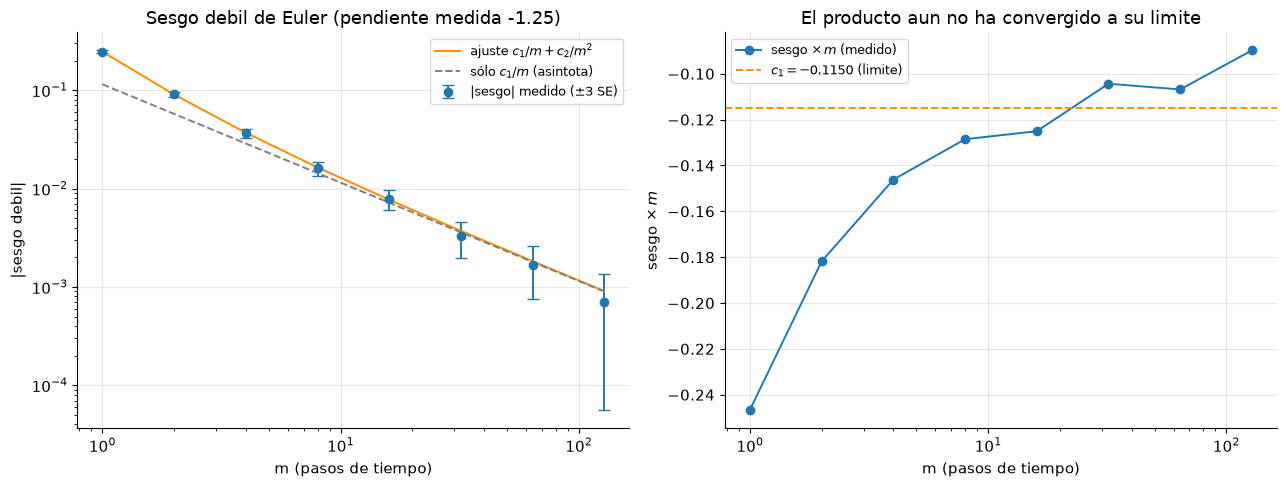

In [4]:
def nested_brownian_increments(n_paths, m_max, T, rng, chunk):
    '''Yield chunks of (n_chunk, m_max) Brownian increments on the finest grid.'''
    done = 0
    while done < n_paths:
        b = min(chunk, n_paths - done)
        yield rng.standard_normal((b, m_max)) * np.sqrt(T / m_max)
        done += b


def euler_terminal(S0, mu, sigma, dW):
    '''Euler-Maruyama terminal value from an (n, m) array of Brownian increments.'''
    m = dW.shape[1]
    dt = T / m
    S = np.full(dW.shape[0], S0)
    for k in range(m):
        S = S * (1.0 + mu * dt + sigma * dW[:, k])
    return S


def milstein_terminal(S0, mu, sigma, dW):
    '''Milstein terminal value (adds the 0.5*sigma^2*(dW^2 - dt) Ito-Taylor term).'''
    m = dW.shape[1]
    dt = T / m
    S = np.full(dW.shape[0], S0)
    for k in range(m):
        S = S * (1.0 + mu * dt + sigma * dW[:, k] + 0.5 * sigma**2 * (dW[:, k] ** 2 - dt))
    return S


m_weak = [1, 2, 4, 8, 16, 32, 64, 128]
n_weak, m_max_weak = 1_000_000, 128
sum_diff = {m: 0.0 for m in m_weak}   # suma de (payoff Euler - payoff exacto), mismos brownianos
sum_diff_sq = {m: 0.0 for m in m_weak}
sum_exact = 0.0
rng_weak = np.random.default_rng(11)
for dW_fine in nested_brownian_increments(n_weak, m_max_weak, T, rng_weak, chunk=50_000):
    b = dW_fine.shape[0]
    S_exact = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * dW_fine.sum(axis=1))
    payoff_exact = np.exp(-r * T) * np.maximum(S_exact - K, 0.0)
    sum_exact += payoff_exact.sum()
    for m in m_weak:
        dW = dW_fine.reshape(b, m, m_max_weak // m).sum(axis=2)  # malla gruesa anidada
        payoff_euler = np.exp(-r * T) * np.maximum(euler_terminal(S0, r - q, sigma, dW) - K, 0.0)
        diff = payoff_euler - payoff_exact
        sum_diff[m] += diff.sum()
        sum_diff_sq[m] += (diff**2).sum()

price_exact_mc = sum_exact / n_weak
weak_bias = np.array([sum_diff[m] / n_weak for m in m_weak])
weak_se = np.array([np.sqrt((sum_diff_sq[m] - n_weak * (sum_diff[m] / n_weak) ** 2) / (n_weak - 1) / n_weak)
                    for m in m_weak])

print(f"Simulador exacto (n={n_weak:,}, brownianos comunes) = {price_exact_mc:.6f}   [BS = {bs_call:.6f}]")
print(f"{'m':>5} | {'Euler':>10} | {'sesgo':>10} | {'SE del sesgo':>12} | {'|sesgo|/SE':>10} | {'sesgo*m':>9}")
print("-" * 72)
for i, m in enumerate(m_weak):
    print(f"{m:>5} | {price_exact_mc + weak_bias[i]:>10.6f} | {weak_bias[i]:>10.6f} | {weak_se[i]:>12.6f} | "
          f"{abs(weak_bias[i])/weak_se[i]:>10.1f} | {weak_bias[i]*m:>9.5f}")

# Diagnostico grueso: pendiente log-log donde el sesgo esta bien resuelto
m_fit = np.array(m_weak[:5], dtype=float)   # m = 1..16
slope_weak = np.polyfit(np.log(m_fit), np.log(np.abs(weak_bias[:5])), 1)[0]

# La afirmacion verificable: la estructura c1/m + c2/m^2 de la expansion debil
design = np.vstack([1.0 / np.array(m_weak), 1.0 / np.array(m_weak, dtype=float) ** 2]).T
coef, *_ = np.linalg.lstsq(design, weak_bias, rcond=None)
fit_two = design @ coef
coef_one, *_ = np.linalg.lstsq(design[:, :1], weak_bias, rcond=None)
fit_one = design[:, :1] @ coef_one
r2 = lambda pred: 1.0 - np.sum((weak_bias - pred) ** 2) / np.sum((weak_bias - weak_bias.mean()) ** 2)
rel_err_fit = np.abs(fit_two[:5] - weak_bias[:5]) / np.abs(weak_bias[:5])

print(f"\npendiente log-log (m=1..16) = {slope_weak:.4f}  <- mas empinada que -1: el termino c2/m^2 aun pesa")
print(f"ajuste de dos terminos: c1 = {coef[0]:.6f}, c2 = {coef[1]:.6f}   (c2/c1 = {coef[1]/coef[0]:.2f})")
print(f"  R^2 con c1/m + c2/m^2 = {r2(fit_two):.6f}")
print(f"  R^2 con solo c1/m     = {r2(fit_one):.6f}   <- el modelo de un termino no describe estos datos")
print(f"  error relativo del ajuste en m<=16: max = {rel_err_fit.max():.4f}")
rel_second = abs(coef[1] / coef[0]) / np.array(m_weak, dtype=float)  # peso relativo de c2/m^2 vs c1/m
print(f"peso relativo del segundo termino: m=1 -> {rel_second[0]:.0%}, m=16 -> {rel_second[4]:.0%}, "
      f"m=128 -> {rel_second[-1]:.1%}")
print("De ahi la pinza: a m chico la pendiente se aleja de -1 por el termino c2/m^2, y a m grande, donde")
print("ese termino ya no importa, el sesgo cae al nivel del ruido residual (|sesgo|/SE baja a 3.3 en m=128).")
print("Ninguno de los dos extremos mide el orden por si solo; el ajuste de dos terminos usa los ocho puntos.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(m_weak, -weak_bias, yerr=3 * weak_se, fmt="o", capsize=4, label="$|$sesgo$|$ medido ($\\pm$3 SE)")
ax.plot(m_weak, -fit_two, "-", color="darkorange", label="ajuste $c_1/m + c_2/m^2$")
ax.plot(m_weak, -coef[0] / np.array(m_weak), "--", color="gray", label="sólo $c_1/m$ (asintota)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("m (pasos de tiempo)"); ax.set_ylabel("$|$sesgo debil$|$")
ax.set_title(f"Sesgo debil de Euler (pendiente medida {slope_weak:.2f})")
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(m_weak, weak_bias * np.array(m_weak), "o-", label="sesgo $\\times\\, m$ (medido)")
ax.axhline(coef[0], color="darkorange", ls="--", label=f"$c_1 = {coef[0]:.4f}$ (limite)")
ax.set_xscale("log")
ax.set_xlabel("m (pasos de tiempo)"); ax.set_ylabel("sesgo $\\times\\, m$")
ax.set_title("El producto aun no ha convergido a su limite")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Demo 4 — error fuerte: Euler contra Milstein

Ahora medimos la otra convergencia: la distancia **trayectoria a trayectoria** $\mathbb{E}|\hat S_T-S_T|$ usando el mismo browniano para el esquema y para la solución exacta. Es el experimento donde Milstein se gana su lugar: no mejora el precio de un europeo (mismo orden débil) pero sigue la trayectoria un orden mejor, que es lo que hace falta cuando el payoff depende del camino.

Nótese que este error **no es un error de precio**: es una distancia entre variables aleatorias. Un esquema puede tener error fuerte grande y aun así dar precios europeos correctos, precisamente porque acierta la distribución sin acertar la trayectoria.

    m |  E|dS| Euler |  E|dS| Milstein |   ratio
--------------------------------------------------
    1 |     2.054604 |        0.712682 |    2.88
    2 |     1.548931 |        0.390520 |    3.97
    4 |     1.136755 |        0.206600 |    5.50
    8 |     0.819660 |        0.107031 |    7.66
   16 |     0.586078 |        0.054512 |   10.75
   32 |     0.416523 |        0.027558 |   15.11
   64 |     0.295342 |        0.013869 |   21.29

pendientes log-log: Euler = -0.4693 (teoria -1/2) | Milstein = -0.9508 (teoria -1)


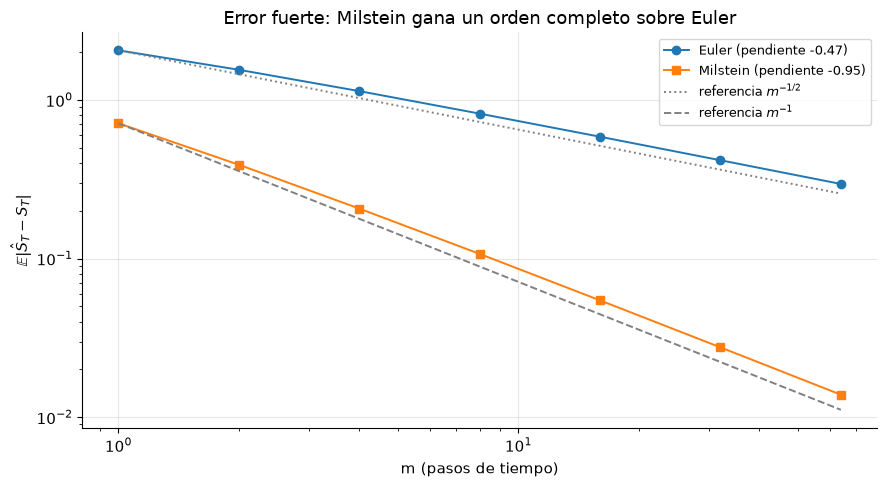

In [5]:
n_strong, m_max_strong = 200_000, 64
m_strong = [1, 2, 4, 8, 16, 32, 64]
rng_strong = np.random.default_rng(13)
dW_fine = rng_strong.standard_normal((n_strong, m_max_strong)) * np.sqrt(T / m_max_strong)
S_exact = S0 * np.exp((r - q - 0.5 * sigma**2) * T + sigma * dW_fine.sum(axis=1))

err_euler, err_milstein = [], []
for m in m_strong:
    dW = dW_fine.reshape(n_strong, m, m_max_strong // m).sum(axis=2)
    err_euler.append(np.abs(euler_terminal(S0, r - q, sigma, dW) - S_exact).mean())
    err_milstein.append(np.abs(milstein_terminal(S0, r - q, sigma, dW) - S_exact).mean())
err_euler, err_milstein = np.array(err_euler), np.array(err_milstein)

slope_eu = np.polyfit(np.log(m_strong), np.log(err_euler), 1)[0]
slope_mi = np.polyfit(np.log(m_strong), np.log(err_milstein), 1)[0]

print(f"{'m':>5} | {'E|dS| Euler':>12} | {'E|dS| Milstein':>15} | {'ratio':>7}")
print("-" * 50)
for m, e, mi in zip(m_strong, err_euler, err_milstein):
    print(f"{m:>5} | {e:>12.6f} | {mi:>15.6f} | {e/mi:>7.2f}")
print(f"\npendientes log-log: Euler = {slope_eu:.4f} (teoria -1/2) | Milstein = {slope_mi:.4f} (teoria -1)")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(m_strong, err_euler, "o-", label=f"Euler (pendiente {slope_eu:.2f})")
ax.plot(m_strong, err_milstein, "s-", label=f"Milstein (pendiente {slope_mi:.2f})")
ax.plot(m_strong, err_euler[0] * (np.array(m_strong) / m_strong[0]) ** -0.5, ":", color="gray",
        label="referencia $m^{-1/2}$")
ax.plot(m_strong, err_milstein[0] * (np.array(m_strong) / m_strong[0]) ** -1.0, "--", color="gray",
        label="referencia $m^{-1}$")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("m (pasos de tiempo)"); ax.set_ylabel("$\\mathbb{E}|\\hat S_T - S_T|$")
ax.set_title("Error fuerte: Milstein gana un orden completo sobre Euler")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 5. Validación

Todo se contrasta contra la referencia exacta de M3 (`bs_price`) y contra los órdenes de convergencia teóricos. Las tolerancias:

1. **MC exacto vs Black-Scholes**, dentro de 3 SE — el estimador sin discretización sí es insesgado, así que aquí el test estadístico es el correcto.
2. **Tasa $n^{-1/2}$**: pendiente log-log de SE vs $n$ en $[-0.52,-0.48]$.
3. **Cobertura del IC**: en $[0.93,0.97]$ con $R=2000$ réplicas (el error de la propia estimación es $\pm0.01$).
4. **Estructura del sesgo débil de Euler.** Lo que se verifica no es "sesgo$\times m$ constante" (el producto aún no converge, ver §3) ni la pendiente por sí sola (sale $\approx-1.2$ porque $c_2$ todavía pesa), sino la **forma funcional** que predice la teoría: el ajuste $c_1/m+c_2/m^2$ debe explicar los datos ($R^2>0.999$, error relativo $\leq5\%$ donde el sesgo está bien resuelto) mientras que el modelo de un solo término no ($R^2<0.99$). Como control adicional, la pendiente debe caer en $[-1.35,-0.85]$ y el sesgo debe ser negativo en todo $m$. Se comprueba además que el experimento tiene resolución para lo que afirma: $|$sesgo$|\geq3$ SE en todo $m$.
5. **Órdenes fuertes**: Euler en $[-0.60,-0.40]$, Milstein en $[-1.15,-0.85]$, y Milstein estrictamente mejor que Euler en todo $m\geq2$.

In [6]:
# 1. MC exacto (sin discretizacion) vs Black-Scholes, dentro de 3 SE
z_mc = abs(means[-1] - bs_call) / ses[-1]
print(f"MC (n={n_grid[-1]:,}) vs BS: |diff|/SE = {z_mc:.3f} (<=3? {z_mc <= 3.0})")
assert z_mc <= 3.0

z_mc_crn = abs(price_exact_mc - bs_call) / (ses[-1])
print(f"MC con brownianos comunes (n={n_weak:,}) vs BS: |diff|/SE = {z_mc_crn:.3f} (<=3? {z_mc_crn <= 3.0})")
assert z_mc_crn <= 3.0

# 2. Tasa n^{-1/2}
print(f"pendiente SE vs n = {slope_se:.4f} (en [-0.52,-0.48]? {-0.52 <= slope_se <= -0.48})")
assert -0.52 <= slope_se <= -0.48

# 3. Cobertura del IC
print(f"cobertura del IC 95% = {coverage:.4f} (en [0.93,0.97]? {0.93 <= coverage <= 0.97})")
assert 0.93 <= coverage <= 0.97

# 4. Estructura del sesgo debil de Euler
print(f"pendiente del sesgo debil (m=1..16) = {slope_weak:.4f} (en [-1.35,-0.85]? {-1.35 <= slope_weak <= -0.85})")
assert -1.35 <= slope_weak <= -0.85
print(f"R^2 de c1/m + c2/m^2 = {r2(fit_two):.6f} (>0.999? {r2(fit_two) > 0.999}) | "
      f"R^2 de solo c1/m = {r2(fit_one):.6f} (<0.99? {r2(fit_one) < 0.99})")
assert r2(fit_two) > 0.999 and r2(fit_one) < 0.99
print(f"error relativo max del ajuste en m<=16 = {rel_err_fit.max():.4f} (<=0.05? {rel_err_fit.max() <= 0.05})")
assert rel_err_fit.max() <= 0.05
assert np.all(weak_bias < 0.0), "el Euler subestima el call en todo m (sesgo de un solo signo)"
resolution = np.abs(weak_bias) / weak_se
print(f"resolucion del experimento: min |sesgo|/SE = {resolution.min():.1f} (>=3? {resolution.min() >= 3.0})")
assert resolution.min() >= 3.0

# 5. Ordenes fuertes
print(f"pendiente fuerte Euler    = {slope_eu:.4f} (en [-0.60,-0.40]? {-0.60 <= slope_eu <= -0.40})")
print(f"pendiente fuerte Milstein = {slope_mi:.4f} (en [-1.15,-0.85]? {-1.15 <= slope_mi <= -0.85})")
assert -0.60 <= slope_eu <= -0.40
assert -1.15 <= slope_mi <= -0.85
assert np.all(err_milstein[1:] < err_euler[1:])

print()
print("Validacion completa: 5/5 dentro de tolerancia.")

MC (n=1,000,000) vs BS: |diff|/SE = 0.488 (<=3? True)
MC con brownianos comunes (n=1,000,000) vs BS: |diff|/SE = 0.070 (<=3? True)
pendiente SE vs n = -0.4951 (en [-0.52,-0.48]? True)
cobertura del IC 95% = 0.9550 (en [0.93,0.97]? True)
pendiente del sesgo debil (m=1..16) = -1.2459 (en [-1.35,-0.85]? True)
R^2 de c1/m + c2/m^2 = 0.999983 (>0.999? True) | R^2 de solo c1/m = 0.969998 (<0.99? True)
error relativo max del ajuste en m<=16 = 0.0223 (<=0.05? True)
resolucion del experimento: min |sesgo|/SE = 3.3 (>=3? True)
pendiente fuerte Euler    = -0.4693 (en [-0.60,-0.40]? True)
pendiente fuerte Milstein = -0.9508 (en [-1.15,-0.85]? True)

Validacion completa: 5/5 dentro de tolerancia.


## Referencias

- Glasserman, P. (2004). *Monte Carlo Methods in Financial Engineering*, Springer, caps. 1 y 6 (fundamentos; discretización de SDEs).
- Kloeden, P.E. & Platen, E. (1992). *Numerical Solution of Stochastic Differential Equations*, Springer, caps. 9-10 (convergencia fuerte y débil, esquema de Milstein).
- Higham, D.J. (2001). *An Algorithmic Introduction to Numerical Simulation of Stochastic Differential Equations*. SIAM Review, 43(3), 525-546. (la referencia corta y legible para los experimentos de esta sección)
- Boyle, P. (1977). *Options: A Monte Carlo Approach*. Journal of Financial Economics, 4(3), 323-338. (el paper fundacional)
- Giles, M.B. (2008). *Multilevel Monte Carlo Path Simulation*. Operations Research, 56(3), 607-617. (por qué el orden fuerte gobierna la eficiencia; fuera del alcance de este notebook)